# Path A Full PICASO Simulation: Proposal-Style First-Order Run

This notebook turns the requested single planet case into the same kind of forward-modeling workflow described in the proposal:

**Planet-typing near the radius valley:** can a volatile-rich, sub-Neptune-like atmosphere produce reflected-light spectra that look confusingly terrestrial?

The notebook uses **Path A** from the workflow diagram:

- `atmosphere_source = "picaso"`
- `thermal_source = "picaso"`
- PICASO generates the atmosphere instead of reading SLGRID files.
- PICASO computes both reflected light and thermal emission.

The main proposal-style change is wavelength coverage: this notebook uses `0.3-2.5 micron`, not the older quick-look `0.3-1.0 micron` Roadrunner grid.

## Abstract / Science Motivation

The proposal asks whether sub-Neptunes near the radius valley can masquerade as terrestrial worlds in low-resolution reflected-light spectra. The problem is degeneracy: radius, clouds, metallicity, phase angle, and atmospheric mean molecular weight can all change the observed planet-star flux ratio and spectral shape.

This first-order run is one concrete test case. It does not yet build the full grid from the proposal, but it is structured like one grid point in that future library: one planet, one host star, one separation, one composition/cloud setup, one phase angle, and a broad reflected-light wavelength range.

## Objectives And Aims For This Notebook

This notebook follows the proposal style by separating the science goal from the computational steps.

1. **Build one Path A forward model.** Use PICASO-generated pressure-temperature structure, chemistry, and clouds.
2. **Use proposal-like wavelength coverage.** Compute spectra from about `0.3-2.5 micron` to capture blue slopes, visible bands, and near-infrared molecular structure.
3. **Record derived physical quantities.** The planet mass is calculated from the requested surface gravity and radius.
4. **Compute diagnostic metrics.** Integrate reflected and thermal flux over Roman CGI bands and broader proposal-style windows.
5. **Save reusable deliverables.** Write spectrum tables, metric tables, summary metadata, and plots.

## Requested Planet Case

Input values from the requested run:

- Metallicity: `10x solar`, represented as `log_mh = +1.0`
- C/O: `1.0`
- Cloud sedimentation: `fsed = 3`
- Clouds: fully cloudy Path A generated cloud model, represented here with Virga clouds
- Separation: `1 AU`
- Phase angle: `60 deg`
- Eddy diffusion: `Kzz = 1e11 cm^2/s`
- Star: Sunlike, `T_star = 5778 K`, `R_star = 1 R_sun`
- Surface gravity: `25 m/s^2`
- Planet radius: `1.5 R_earth`

Because this is Path A, the notebook does **not** read the SLGRID `m+100_CO100_fsed3` files. The equivalent physical choices are passed into PICASO's generated atmosphere path.

## Methodology Overview

The Path A calculation proceeds like this:

1. Set environment paths for the local PICASO4 reference data.
2. Calculate mass from `M = g R^2 / G`.
3. Build `SystemParams` for the requested planet-star geometry.
4. Ask PICASO to generate the atmosphere with Guillot PT, Visscher chemistry, and Virga clouds.
5. Compute reflected light at the requested phase angle.
6. Compute thermal emission at phase `0`, as required by the 1-D thermal calculation.
7. Resample both spectra onto the proposal-style `0.3-2.5 micron` wavelength grid.
8. Integrate over diagnostic windows and save figures/tables.

## 1. Environment Setup

Run this notebook with the **Python (picaso4)** kernel. The first cell sets local data paths before importing Roadrunner/PICASO. It also points Numba and Matplotlib caches to writable project folders so PICASO imports cleanly.

In [1]:
from __future__ import annotations

import json
import math
import os
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "roadrunner_egp").exists() and (candidate / "picaso4_reference").exists():
            return candidate
    raise RuntimeError("Could not find aurora project root from current directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
ROADRUNNER_ROOT = PROJECT_ROOT / "roadrunner_egp"
RESULT_DIR = ROADRUNNER_ROOT / "results" / "path_a_proposal_range"
TMP_DIR = PROJECT_ROOT / "tmp"
PROPOSAL_TEXT = PROJECT_ROOT / "docs" / "project_context" / "proposal" / "Daniel_Huang_AABC_Grant_Proposal_final.txt"

for path in (RESULT_DIR, TMP_DIR / "matplotlib", TMP_DIR / "numba-cache"):
    path.mkdir(parents=True, exist_ok=True)

os.environ["ROADRUNNER_SCIENCE_INPUTS"] = str(PROJECT_ROOT / "science_inputs")
os.environ["picaso_refdata"] = str(PROJECT_ROOT / "picaso4_reference")
os.environ["PYSYN_CDBS"] = str(PROJECT_ROOT / "picaso4_reference" / "stellar_grids")
os.environ["SLGRID_BASE_DIR"] = str(PROJECT_ROOT / "science_inputs" / "slgrid")
os.environ["SLGRID_PT_DIR"] = str(PROJECT_ROOT / "science_inputs" / "slgrid" / "climate")
os.environ["SLGRID_CLD_DIR"] = str(PROJECT_ROOT / "science_inputs" / "slgrid" / "clouds")
os.environ["EGP_IRFLUX_DIR"] = str(PROJECT_ROOT / "science_inputs" / "egp" / "irflux")
os.environ["MPLCONFIGDIR"] = str(TMP_DIR / "matplotlib")
os.environ["NUMBA_CACHE_DIR"] = str(TMP_DIR / "numba-cache")

if str(ROADRUNNER_ROOT) not in sys.path:
    sys.path.insert(0, str(ROADRUNNER_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Proposal text: {PROPOSAL_TEXT}")
print(f"Results will be written to: {RESULT_DIR}")
print(f"Python executable: {sys.executable}")

Project root: /Users/dhuang/Documents/daniel/research/aurora
Proposal text: /Users/dhuang/Documents/daniel/research/aurora/docs/project_context/proposal/Daniel_Huang_AABC_Grant_Proposal_final.txt
Results will be written to: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range
Python executable: /Users/dhuang/Documents/daniel/research/aurora/.venv-picaso4/bin/python


## 2. Imports And Proposal Wavelength Grid

The old Roadrunner quick-look grid was `0.3-1.0 micron`. The proposal explicitly calls for a broader reflected-light range of roughly `0.3-2.5 micron`, so this notebook defines its own grid.

`2201` is just the number of sampled wavelength points. It gives one point every `0.001 micron` across the `0.3-2.5 micron` interval.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from astropy import units as u
from astropy.constants import G, M_earth, M_jup, R_earth, R_jup, au

from roadrunner.config import CGI_BANDS, REFLECT_THRESHOLD, R_STAR_Rsun, T_STAR_K
from roadrunner.physics import top_hat
from roadrunner.runner import equilibrium_temperature, extract_planet_fluxes, run_picaso_once
from roadrunner.system import SystemParams

PROPOSAL_WAVELENGTH_MIN_UM = 0.3
PROPOSAL_WAVELENGTH_MAX_UM = 2.5
POINTS_PER_MICRON = 1000
N_WAVELENGTH_POINTS = int((PROPOSAL_WAVELENGTH_MAX_UM - PROPOSAL_WAVELENGTH_MIN_UM) * POINTS_PER_MICRON) + 1
LAM_GRID = np.linspace(PROPOSAL_WAVELENGTH_MIN_UM, PROPOSAL_WAVELENGTH_MAX_UM, N_WAVELENGTH_POINTS)

print(f"Proposal-style wavelength grid: {LAM_GRID.size} points")
print(f"Range: {LAM_GRID.min():.3f}-{LAM_GRID.max():.3f} micron")
print(f"Spacing: {np.diff(LAM_GRID).mean():.4f} micron")
print(f"Reflected-fraction decision threshold: {REFLECT_THRESHOLD:.0%}")

Matplotlib is building the font cache; this may take a moment.


Proposal-style wavelength grid: 2201 points
Range: 0.300-2.500 micron
Spacing: 0.0010 micron
Reflected-fraction decision threshold: 10%


## 3. Diagnostic Windows

The proposal emphasizes feature combinations rather than only Roman CGI bands. This notebook keeps the Roman CGI windows and adds broader proposal-style windows for:

- blue/Rayleigh slope behavior,
- visible continuum shape,
- water and methane structure near `0.9-1.8 micron`,
- longer-wavelength continuum/CIA-sensitive behavior near `2.1-2.35 micron`.

These are first-order windows, not final mission bandpasses.

In [3]:
PROPOSAL_WINDOWS = {
    "Rayleigh-blue": (0.35, 0.50),
    "Visible-continuum": (0.50, 0.80),
    "H2O-0.94": (0.90, 1.05),
    "CH4-H2O-1.15": (1.10, 1.30),
    "H2O-1.4": (1.32, 1.52),
    "CH4-H2O-1.7": (1.55, 1.80),
    "K-CIA-2.2": (2.05, 2.35),
}

analysis_windows = {**CGI_BANDS, **PROPOSAL_WINDOWS}
window_filters = {
    name: top_hat(LAM_GRID, lo, hi)
    for name, (lo, hi) in analysis_windows.items()
}

window_table = pd.DataFrame(
    [
        {
            "window": name,
            "lo_um": lo,
            "hi_um": hi,
            "kind": "Roman CGI" if name in CGI_BANDS else "proposal diagnostic",
        }
        for name, (lo, hi) in analysis_windows.items()
    ]
)
window_table

,window,lo_um,hi_um,kind
0,CGI-1,0.546,0.604,Roman CGI
1,CGI-2,0.610,0.710,Roman CGI
2,CGI-3,0.675,0.785,Roman CGI
3,CGI-4,0.783,0.867,Roman CGI
4,Rayleigh-blue,0.350,0.500,proposal diagnostic
5,Visible-continuum,0.500,0.800,proposal diagnostic
6,H2O-0.94,0.900,1.050,proposal diagnostic
7,CH4-H2O-1.15,1.100,1.300,proposal diagnostic
8,H2O-1.4,1.320,1.520,proposal diagnostic
9,CH4-H2O-1.7,1.550,1.800,proposal diagnostic


## 4. Input Table And Mass Calculation

The mass is derived from the requested radius and gravity:

`M = g R^2 / G`

This is important for proposal-style documentation because the simulation should record not only the parameters we typed in, but also the physical quantities implied by them.

In [4]:
requested = {
    "metallicity_x_solar": 10.0,
    "chem_log_mh": 1.0,
    "chem_c_o": 1.0,
    "fsed": 3.0,
    "cloud_model": "virga",
    "cloud_cover_note": "fully cloudy Path A generated cloud model",
    "semi_major_au": 1.0,
    "phase_deg": 60.0,
    "kzz_cgs": 1.0e11,
    "star_teff_k": T_STAR_K,
    "star_radius_rsun": R_STAR_Rsun,
    "gravity_m_s2": 25.0,
    "radius_rearth": 1.5,
    "teff_k_for_tint": 1000.0,
}

radius = requested["radius_rearth"] * R_earth
surface_gravity = requested["gravity_m_s2"] * u.m / u.s**2
mass = (surface_gravity * radius**2 / G).to(u.kg)

radius_rjup = (radius / R_jup).decompose().value
logg_cgs = math.log10(surface_gravity.to(u.cm / u.s**2).value)
mass_mearth = (mass / M_earth).decompose().value
mass_mjup = (mass / M_jup).decompose().value

mass_table = pd.DataFrame(
    [
        ("radius", requested["radius_rearth"], "R_earth"),
        ("radius", radius_rjup, "R_jup"),
        ("gravity", requested["gravity_m_s2"], "m/s^2"),
        ("gravity", surface_gravity.to(u.cm / u.s**2).value, "cm/s^2"),
        ("logg", logg_cgs, "log10(cm/s^2)"),
        ("mass", mass.value, "kg"),
        ("mass", mass_mearth, "M_earth"),
        ("mass", mass_mjup, "M_jup"),
    ],
    columns=["quantity", "value", "unit"],
)

mass_table

,quantity,value,unit
0,radius,1.500000e+00,R_earth
1,radius,1.338213e-01,R_jup
2,gravity,2.500000e+01,m/s^2
3,gravity,2.500000e+03,cm/s^2
4,logg,3.397940e+00,log10(cm/s^2)
5,mass,3.428463e+25,kg
6,mass,5.740734e+00,M_earth
7,mass,1.806237e-02,M_jup


## 5. Build The Path A System

Path A uses generated PICASO inputs:

- `atmosphere_source="picaso"` avoids SLGRID pressure-temperature and cloud files.
- `cloud_model="virga"` asks PICASO/Virga to generate clouds.
- `chem_log_mh=1.0` means `10x solar` metallicity.
- `chem_c_o=1.0` sets C/O to 1.
- `kzz_cgs=1e11` is injected into the generated atmosphere profile before Virga clouds are calculated.
- `virga_fsed=3` sets the requested sedimentation efficiency.

`teff_k` is used by the current Path A code as the internal temperature `T_int`; the Sunlike `1 AU` equilibrium temperature is computed separately.

In [5]:
system = SystemParams(
    teff_k=requested["teff_k_for_tint"],
    logg_cgs=logg_cgs,
    rj=radius_rjup,
    a_au=requested["semi_major_au"],
    phase_deg=requested["phase_deg"],
    tstar_k=requested["star_teff_k"],
    rstar_rsun=requested["star_radius_rsun"],
    atmosphere_source="picaso",
    cloud_model=requested["cloud_model"],
    bond_albedo=0.0,
    chem_c_o=requested["chem_c_o"],
    chem_log_mh=requested["chem_log_mh"],
    kzz_cgs=requested["kzz_cgs"],
    virga_fsed=requested["fsed"],
)

teq_k = equilibrium_temperature(system)

system_table = pd.DataFrame(
    [
        ("Path", "A: Full PICASO"),
        ("thermal_source", "picaso"),
        ("atmosphere_source", system.atmosphere_source),
        ("cloud_model", system.cloud_model),
        ("T_int / teff_k", f"{system.teff_k:.1f} K"),
        ("computed Teq", f"{teq_k:.1f} K"),
        ("phase", f"{system.phase_deg:.1f} deg"),
        ("semi_major", f"{system.a_au:.2f} AU"),
        ("C/O", f"{system.chem_c_o:.2f}"),
        ("log_mh", f"{system.chem_log_mh:.2f}"),
        ("Kzz", f"{system.kzz_cgs:.2e} cm^2/s"),
        ("fsed", f"{system.virga_fsed:.1f}"),
    ],
    columns=["setting", "value"],
)

system_table

,setting,value
0,Path,A: Full PICASO
1,thermal_source,picaso
2,atmosphere_source,picaso
3,cloud_model,virga
4,T_int / teff_k,1000.0 K
5,computed Teq,278.6 K
6,phase,60.0 deg
7,semi_major,1.00 AU
8,C/O,1.00
9,log_mh,1.00


## 6. Run Full PICASO Path A

This is the model run. PICASO will generate the atmosphere, compute reflected light at `60 deg`, compute thermal emission at phase `0`, and return spectra that we resample onto the proposal-style `0.3-2.5 micron` grid.

In [6]:
out_ref, out_em = run_picaso_once(
    system,
    LAM_GRID,
    atmosphere_source="picaso",
    cloud_model="virga",
    verbose=True,
)

lam_um, fp_reflected, fp_thermal = extract_planet_fluxes(
    out_ref,
    out_em,
    LAM_GRID,
    system,
)

print("Path A PICASO run complete.")
print(f"Reflected flux finite points: {np.isfinite(fp_reflected).sum()} / {fp_reflected.size}")
print(f"Thermal flux finite points: {np.isfinite(fp_thermal).sum()} / {fp_thermal.size}")
print(f"Wavelength range: {lam_um.min():.3f}-{lam_um.max():.3f} micron")

/Users/dhuang/Documents/daniel/research/aurora/.venv-picaso4/lib/python3.12/site-packages/picaso/justdoit.py:3094: UserWarning: chemeq_visscher() function now points an older version of the visscher table (1060 vs. 2121). The newer version was published in PICASO4 (Mang et al. 2026). In 2121, C/O is now specified as an absolute quantity, rather than a relative to solar quantity. Because of this big change we will use PICASO 4 to warn users but continue pointing this function to the 1060 version. In PICASO 5 we will fully move the chemeq_visscher function (and future versions there of) to utilize absolute C/O quantities. We recommend switching to using chemeq_visscher_2121() as you will see throughout our tutorials. In the future we will point chemeq_visscher simply to chemeq_visscher_2121 and input variable c_o will become c_o_absolute
  warnings.warn(msg)


✓ Using generated PICASO atmosphere (Guillot PT, Teq=278.6 K, Virga MgSiO3, fsed=3)
Path A PICASO run complete.
Reflected flux finite points: 2201 / 2201
Thermal flux finite points: 2201 / 2201
Wavelength range: 0.300-2.500 micron


## 7. Cloud-Free vs Cloudy Comparison

This cell makes the plot you asked for: one Path A run with **no clouds** and one Path A run **with clouds**.

- **Cloud-free** uses the same generated PICASO atmosphere but skips the cloud call.
- **Cloudy** reuses the main Path A Virga cloud run from the previous cell (`fsed = 3`).

The top panel is geometric albedo. The bottom panel is reflected-light planet-star flux ratio. This mirrors the old comparison figure, but the cloudy case here is the requested Path A Virga cloud model rather than an old gray-cloud parameterization.

/Users/dhuang/Documents/daniel/research/aurora/.venv-picaso4/lib/python3.12/site-packages/picaso/justdoit.py:3094: UserWarning: chemeq_visscher() function now points an older version of the visscher table (1060 vs. 2121). The newer version was published in PICASO4 (Mang et al. 2026). In 2121, C/O is now specified as an absolute quantity, rather than a relative to solar quantity. Because of this big change we will use PICASO 4 to warn users but continue pointing this function to the 1060 version. In PICASO 5 we will fully move the chemeq_visscher function (and future versions there of) to utilize absolute C/O quantities. We recommend switching to using chemeq_visscher_2121() as you will see throughout our tutorials. In the future we will point chemeq_visscher simply to chemeq_visscher_2121 and input variable c_o will become c_o_absolute
  warnings.warn(msg)


✓ Using generated PICASO atmosphere (Guillot PT, Teq=278.6 K, cloud-free)


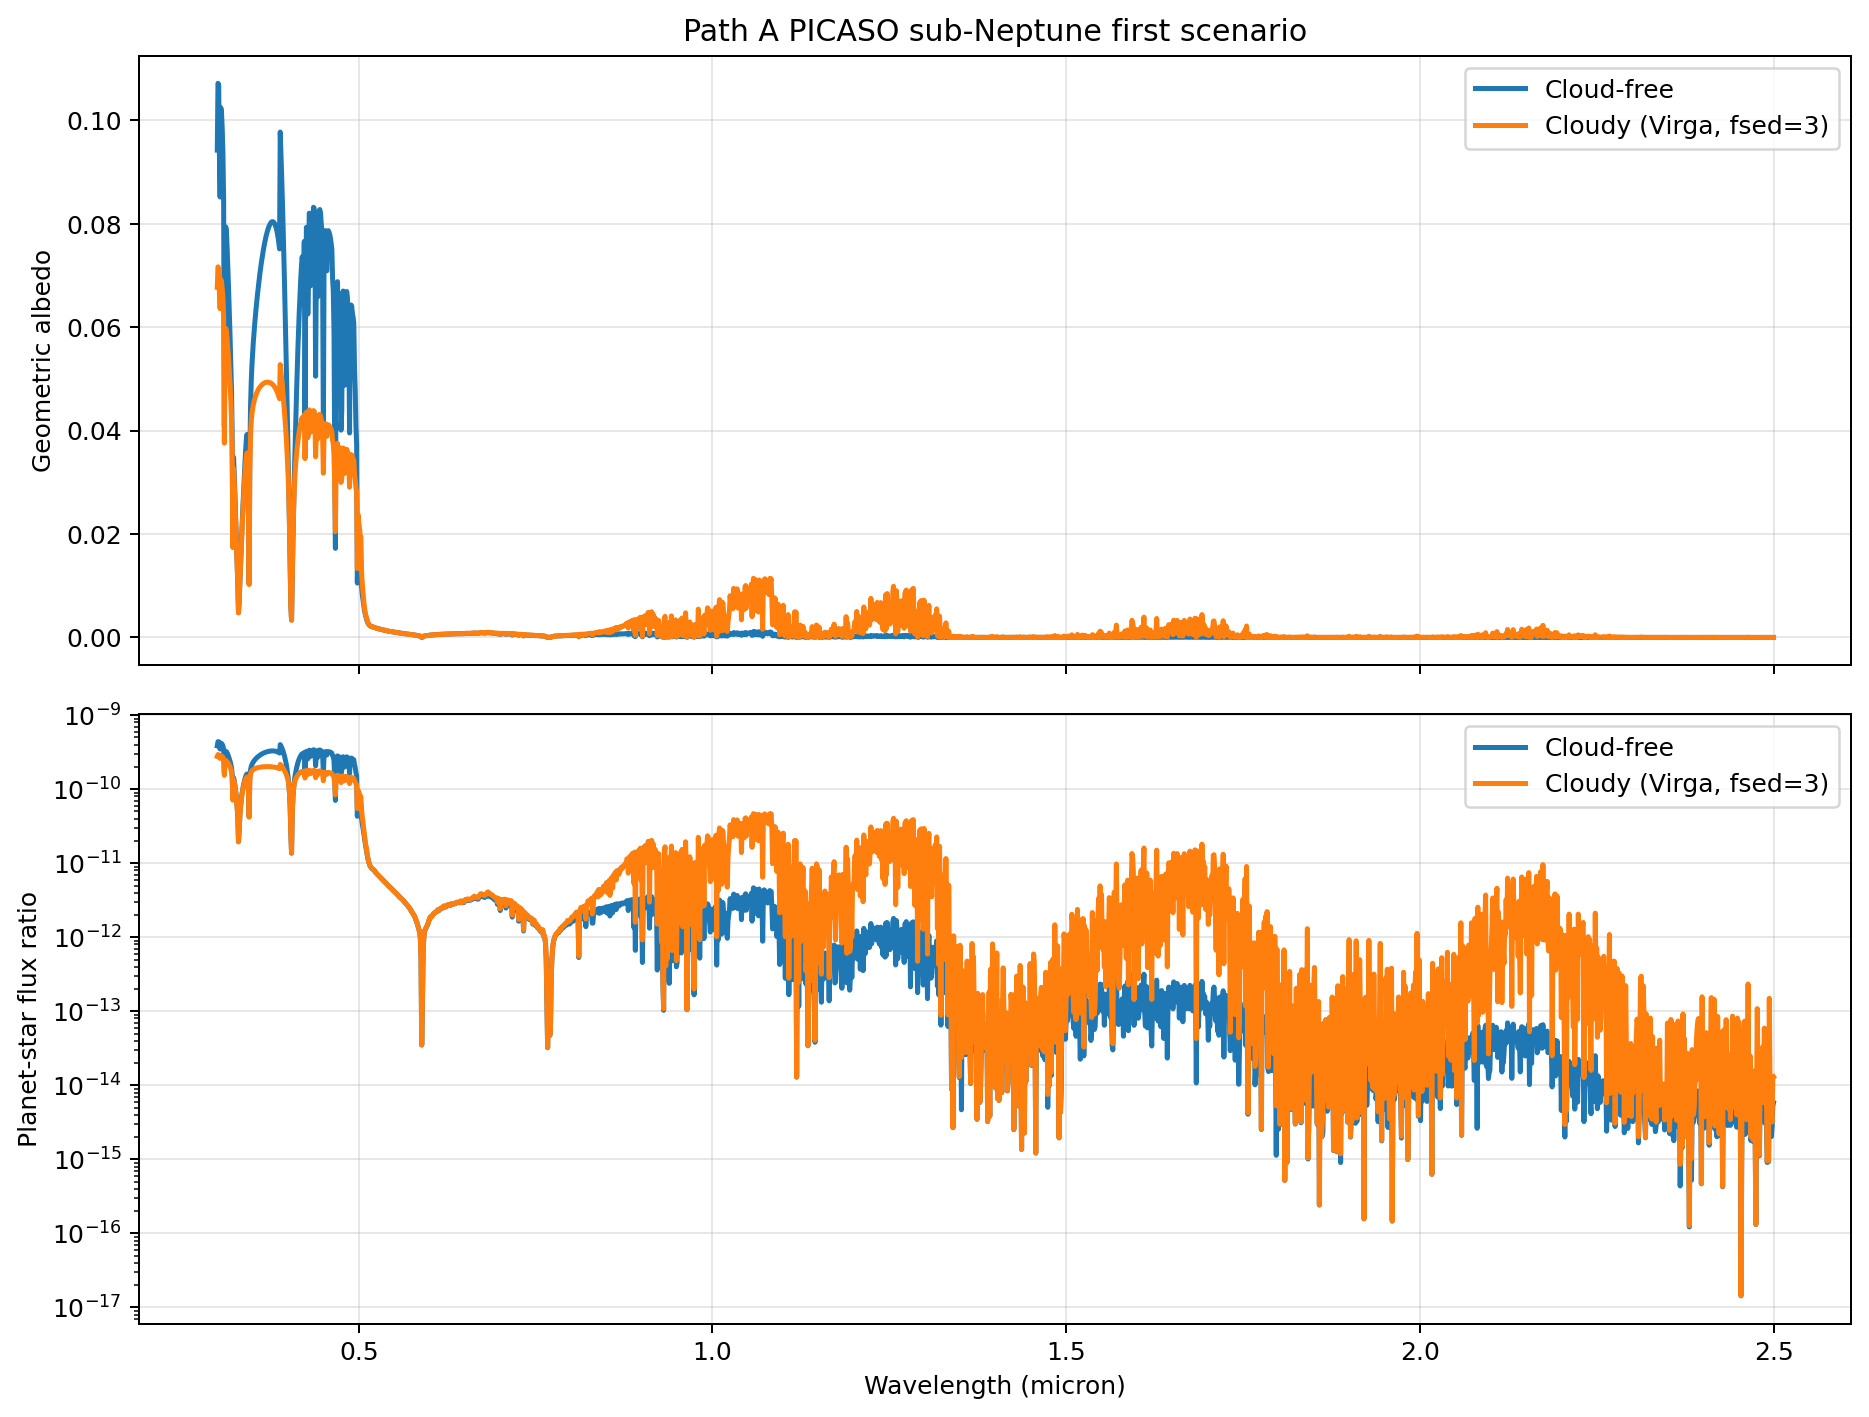

Wrote:
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/cloud_comparison_spectrum.csv
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/cloud_free_vs_cloudy.png


,wavelength_um,geometric_albedo_cloud_free,geometric_albedo_cloudy_virga,fpfs_reflected_cloud_free,fpfs_reflected_cloudy_virga
0,0.300,0.094243,0.067711,3.854461e-10,2.769307e-10
1,0.301,0.107159,0.071669,4.382712e-10,2.931192e-10
2,0.302,0.106890,0.071342,4.371721e-10,2.917820e-10
3,0.303,0.093644,0.066848,3.829979e-10,2.734039e-10
4,0.304,0.085171,0.063565,3.483410e-10,2.599772e-10


In [7]:
def positive_only_for_plot(values):
    values = np.asarray(values, dtype=float)
    return np.where(values > 0, values, np.nan)


def reflected_observables(out_reflected, sys_params, output_grid):
    """Return geometric albedo and reflected planet/star flux ratio on output_grid."""
    native_wavelength_um = 1.0e4 / np.asarray(out_reflected["wavenumber"], dtype=float)
    native_albedo = np.asarray(out_reflected["albedo"], dtype=float)

    fpfs_data = out_reflected.get("fpfs_reflected")
    if isinstance(fpfs_data, np.ndarray):
        native_fpfs = np.asarray(fpfs_data, dtype=float)
    else:
        rp_m = sys_params.rj * R_jup.value
        a_m = sys_params.a_au * au.value
        native_fpfs = native_albedo * (rp_m / a_m) ** 2

    order = np.argsort(native_wavelength_um)
    wavelength_sorted = native_wavelength_um[order]
    albedo_sorted = native_albedo[order]
    fpfs_sorted = native_fpfs[order]

    albedo_grid = np.interp(output_grid, wavelength_sorted, albedo_sorted, left=albedo_sorted[0], right=albedo_sorted[-1])
    fpfs_grid = np.interp(output_grid, wavelength_sorted, fpfs_sorted, left=fpfs_sorted[0], right=fpfs_sorted[-1])
    return albedo_grid, fpfs_grid


cloud_free_system = SystemParams(
    teff_k=system.teff_k,
    logg_cgs=system.logg_cgs,
    rj=system.rj,
    a_au=system.a_au,
    phase_deg=system.phase_deg,
    tstar_k=system.tstar_k,
    rstar_rsun=system.rstar_rsun,
    atmosphere_source="picaso",
    cloud_model="none",
    bond_albedo=system.bond_albedo,
    chem_c_o=system.chem_c_o,
    chem_log_mh=system.chem_log_mh,
    kzz_cgs=system.kzz_cgs,
    virga_fsed=system.virga_fsed,
)

out_ref_cloud_free, _ = run_picaso_once(
    cloud_free_system,
    LAM_GRID,
    atmosphere_source="picaso",
    cloud_model="none",
    verbose=True,
)

albedo_cloud_free, fpfs_cloud_free = reflected_observables(out_ref_cloud_free, cloud_free_system, LAM_GRID)
albedo_cloudy, fpfs_cloudy = reflected_observables(out_ref, system, LAM_GRID)

cloud_comparison_df = pd.DataFrame(
    {
        "wavelength_um": LAM_GRID,
        "geometric_albedo_cloud_free": albedo_cloud_free,
        "geometric_albedo_cloudy_virga": albedo_cloudy,
        "fpfs_reflected_cloud_free": fpfs_cloud_free,
        "fpfs_reflected_cloudy_virga": fpfs_cloudy,
    }
)
cloud_comparison_df.to_csv(RESULT_DIR / "cloud_comparison_spectrum.csv", index=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 8.0), sharex=True)

ax1.plot(LAM_GRID, albedo_cloud_free, label="Cloud-free", linewidth=2)
ax1.plot(LAM_GRID, albedo_cloudy, label="Cloudy (Virga, fsed=3)", linewidth=2)
ax1.set_ylabel("Geometric albedo")
ax1.set_title("Path A PICASO sub-Neptune first scenario")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(LAM_GRID, positive_only_for_plot(fpfs_cloud_free), label="Cloud-free", linewidth=2)
ax2.plot(LAM_GRID, positive_only_for_plot(fpfs_cloudy), label="Cloudy (Virga, fsed=3)", linewidth=2)
ax2.set_yscale("log")
ax2.set_xlabel("Wavelength (micron)")
ax2.set_ylabel("Planet-star flux ratio")
ax2.grid(alpha=0.3)
ax2.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / "cloud_free_vs_cloudy.png", dpi=180, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(RESULT_DIR / "cloud_free_vs_cloudy.png")))

print("Wrote:")
print(f"- {RESULT_DIR / 'cloud_comparison_spectrum.csv'}")
print(f"- {RESULT_DIR / 'cloud_free_vs_cloudy.png'}")
cloud_comparison_df.head()

## 8. Diagnostic Metrics

For each window, the notebook integrates reflected and thermal flux and computes:

`f_reflect = F_reflected / (F_reflected + F_thermal)`

This metric is not the full confusion analysis yet, but it is the same kind of physically interpretable diagnostic the proposal describes.

In [8]:
def integrate_band(lam, flux, transmission):
    mask = np.isfinite(lam) & np.isfinite(flux) & np.isfinite(transmission)
    if mask.sum() < 2:
        return np.nan
    return np.trapezoid(flux[mask] * transmission[mask], lam[mask])

metric_records = []
for name, transmission in window_filters.items():
    lo, hi = analysis_windows[name]
    fp_ref_band = integrate_band(LAM_GRID, fp_reflected, transmission)
    fp_th_band = integrate_band(LAM_GRID, fp_thermal, transmission)
    denom = fp_ref_band + fp_th_band
    f_reflect = fp_ref_band / denom if denom > 0 else np.nan
    metric_records.append(
        {
            "window": name,
            "kind": "Roman CGI" if name in CGI_BANDS else "proposal diagnostic",
            "lo_um": lo,
            "hi_um": hi,
            "f_reflect": f_reflect,
            "Fp_ref_band": fp_ref_band,
            "Fp_th_band": fp_th_band,
            "decision": bool(f_reflect >= REFLECT_THRESHOLD) if np.isfinite(f_reflect) else False,
            "T_eff": system.teff_k,
            "logg": system.logg_cgs,
            "R_p_Rj": system.rj,
            "a_AU": system.a_au,
            "phase_deg": system.phase_deg,
            "thermal_source": "picaso",
            "atmosphere_source": "picaso",
            "chem_log_mh": system.chem_log_mh,
            "chem_c_o": system.chem_c_o,
            "kzz_cgs": system.kzz_cgs,
            "fsed": system.virga_fsed,
        }
    )

metric_df = pd.DataFrame(metric_records)
metric_df

,window,kind,lo_um,hi_um,f_reflect,Fp_ref_band,Fp_th_band,decision,T_eff,logg,R_p_Rj,a_AU,phase_deg,thermal_source,atmosphere_source,chem_log_mh,chem_c_o,kzz_cgs,fsed
0,CGI-1,Roman CGI,0.546,0.604,3.763251e-03,0.011276,2.985145e+00,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
1,CGI-2,Roman CGI,0.610,0.710,8.717341e-06,0.022334,2.562027e+03,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
2,CGI-3,Roman CGI,0.675,0.785,2.918447e-06,0.015678,5.371852e+03,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
3,CGI-4,Roman CGI,0.783,0.867,1.271211e-07,0.013745,1.081237e+05,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
4,Rayleigh-blue,proposal diagnostic,0.350,0.500,3.510043e-06,1.792829,5.107693e+05,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
5,Visible-continuum,proposal diagnostic,0.500,0.800,1.204985e-05,0.110730,9.189246e+03,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
6,H2O-0.94,proposal diagnostic,0.900,1.050,2.584685e-08,0.069950,2.706336e+06,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
7,CH4-H2O-1.15,proposal diagnostic,1.100,1.300,7.379745e-09,0.046504,6.301546e+06,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
8,H2O-1.4,proposal diagnostic,1.320,1.520,1.254384e-09,0.001564,1.246712e+06,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0
9,CH4-H2O-1.7,proposal diagnostic,1.550,1.800,1.042897e-09,0.007889,7.564372e+06,False,1000.0,3.39794,0.133821,1.0,60.0,picaso,picaso,1.0,1.0,1.000000e+11,3.0


## 9. Save Proposal-Style Deliverables

This writes a small single-case deliverable set under `roadrunner_egp/results/path_a_proposal_range/`:

- `summary.json`: inputs, derived values, and output paths
- `diagnostic_metrics.csv`: integrated windows and reflected fractions
- `spectrum.csv`: full `0.3-2.5 micron` spectrum
- `cloud_comparison_spectrum.csv`: cloud-free vs cloudy geometric albedo and reflected planet-star flux ratio

In [9]:
reflected_to_thermal = np.full_like(fp_reflected, np.nan, dtype=float)
np.divide(
    fp_reflected,
    fp_thermal,
    out=reflected_to_thermal,
    where=fp_thermal > 0,
)

spectrum_df = pd.DataFrame(
    {
        "wavelength_um": lam_um,
        "Fp_reflected": fp_reflected,
        "Fp_thermal": fp_thermal,
        "Fp_total": fp_reflected + fp_thermal,
        "reflected_to_thermal": reflected_to_thermal,
    }
)

summary = {
    "path": "A: full PICASO",
    "proposal_framing": "radius-valley planet typing with broad reflected-light wavelength coverage",
    "thermal_source": "picaso",
    "atmosphere_source": "picaso",
    "proposal_reference": str(PROPOSAL_TEXT),
    "wavelength_grid": {
        "min_um": PROPOSAL_WAVELENGTH_MIN_UM,
        "max_um": PROPOSAL_WAVELENGTH_MAX_UM,
        "n_points": int(LAM_GRID.size),
        "spacing_um": float(np.diff(LAM_GRID).mean()),
    },
    "requested_inputs": requested,
    "derived": {
        "radius_rjup": radius_rjup,
        "gravity_cgs": surface_gravity.to(u.cm / u.s**2).value,
        "logg_cgs": logg_cgs,
        "mass_kg": mass.value,
        "mass_mearth": mass_mearth,
        "mass_mjup": mass_mjup,
        "equilibrium_temperature_k": teq_k,
    },
    "output_files": {
        "diagnostic_metrics_csv": str(RESULT_DIR / "diagnostic_metrics.csv"),
        "spectrum_csv": str(RESULT_DIR / "spectrum.csv"),
        "summary_json": str(RESULT_DIR / "summary.json"),
        "spectrum_png": str(RESULT_DIR / "spectrum.png"),
        "diagnostic_reflected_fraction_png": str(RESULT_DIR / "diagnostic_reflected_fraction.png"),
        "cloud_comparison_csv": str(RESULT_DIR / "cloud_comparison_spectrum.csv"),
        "cloud_comparison_png": str(RESULT_DIR / "cloud_free_vs_cloudy.png"),
    },
}

(RESULT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
metric_df.to_csv(RESULT_DIR / "diagnostic_metrics.csv", index=False)
spectrum_df.to_csv(RESULT_DIR / "spectrum.csv", index=False)

print("Wrote:")
for path in [RESULT_DIR / "summary.json", RESULT_DIR / "diagnostic_metrics.csv", RESULT_DIR / "spectrum.csv"]:
    print(f"- {path}")

Wrote:
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/summary.json
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/diagnostic_metrics.csv
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/spectrum.csv


## 10. Spectrum And Metric Figures

The first figure is the broad `0.3-2.5 micron` spectrum. The shaded regions mark the proposal-style diagnostic windows.

The second figure shows `f_reflect` by window. In this specific warm first-order case, thermal emission dominates many windows, which is itself useful context for planet-typing interpretation.

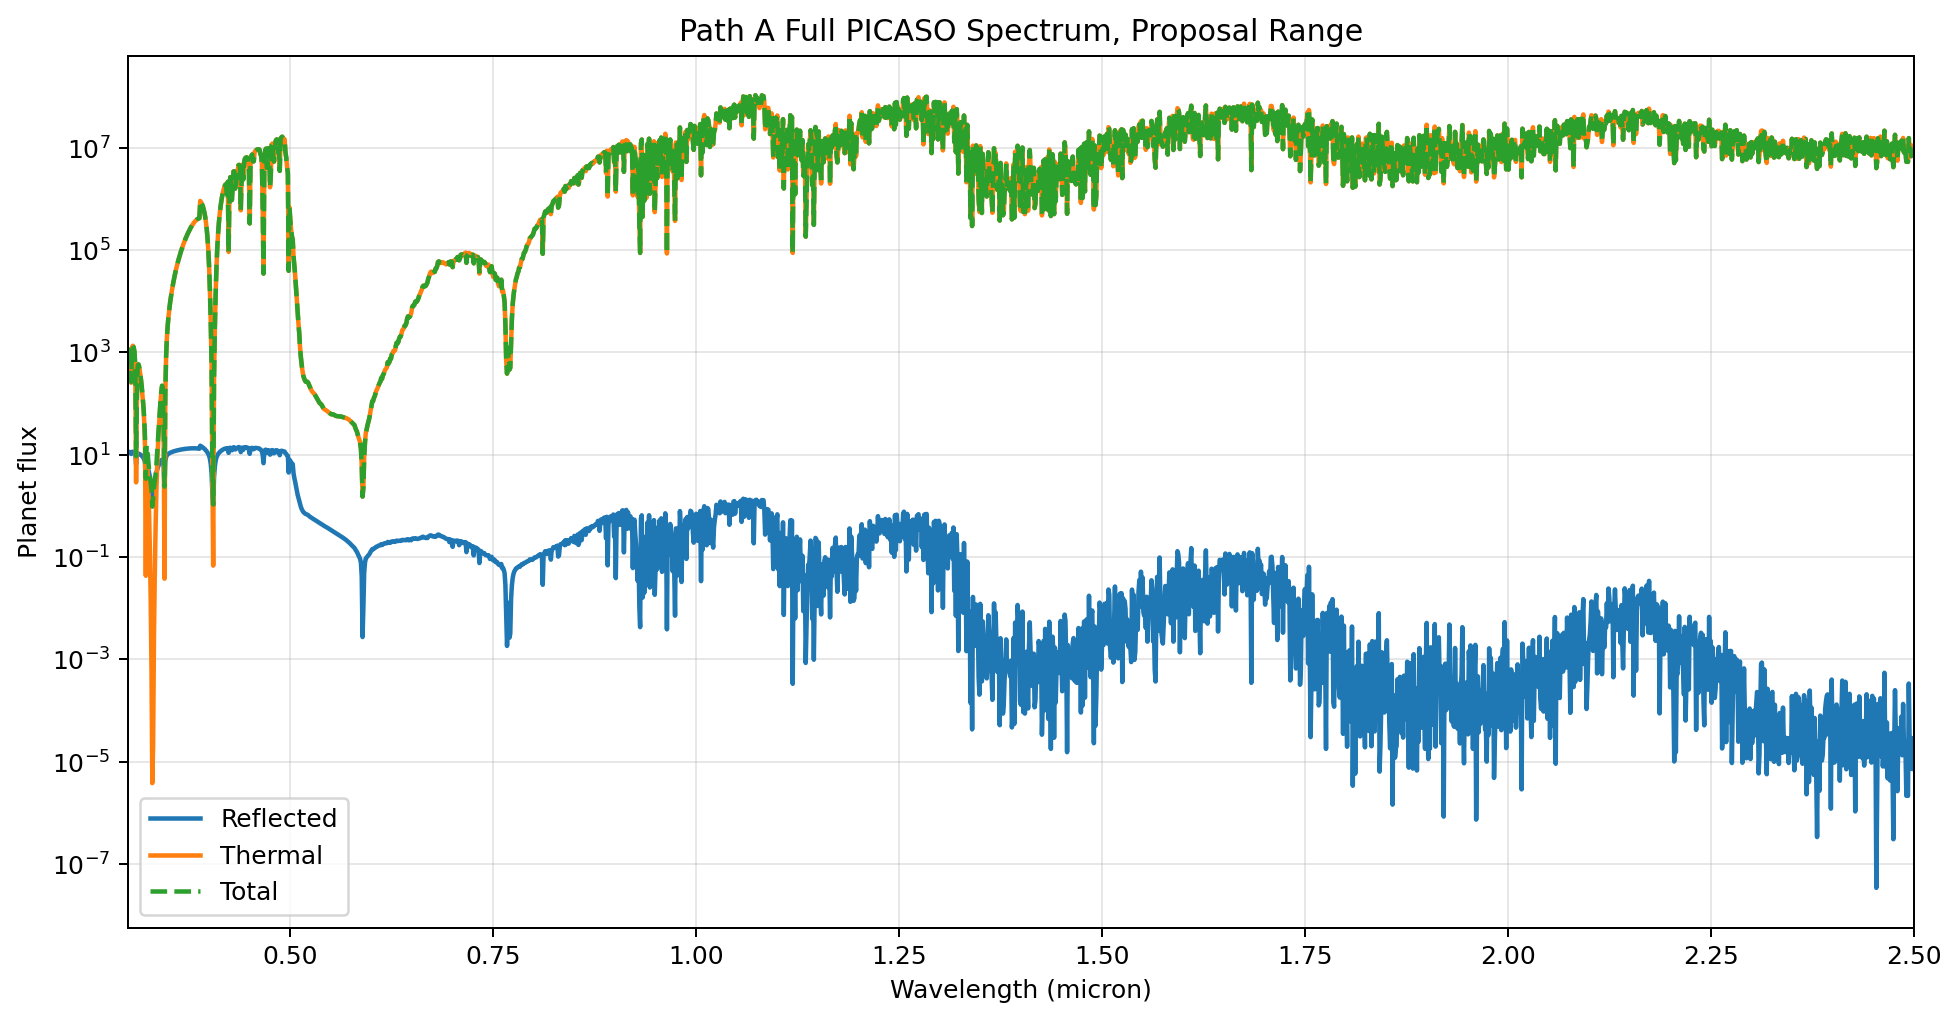

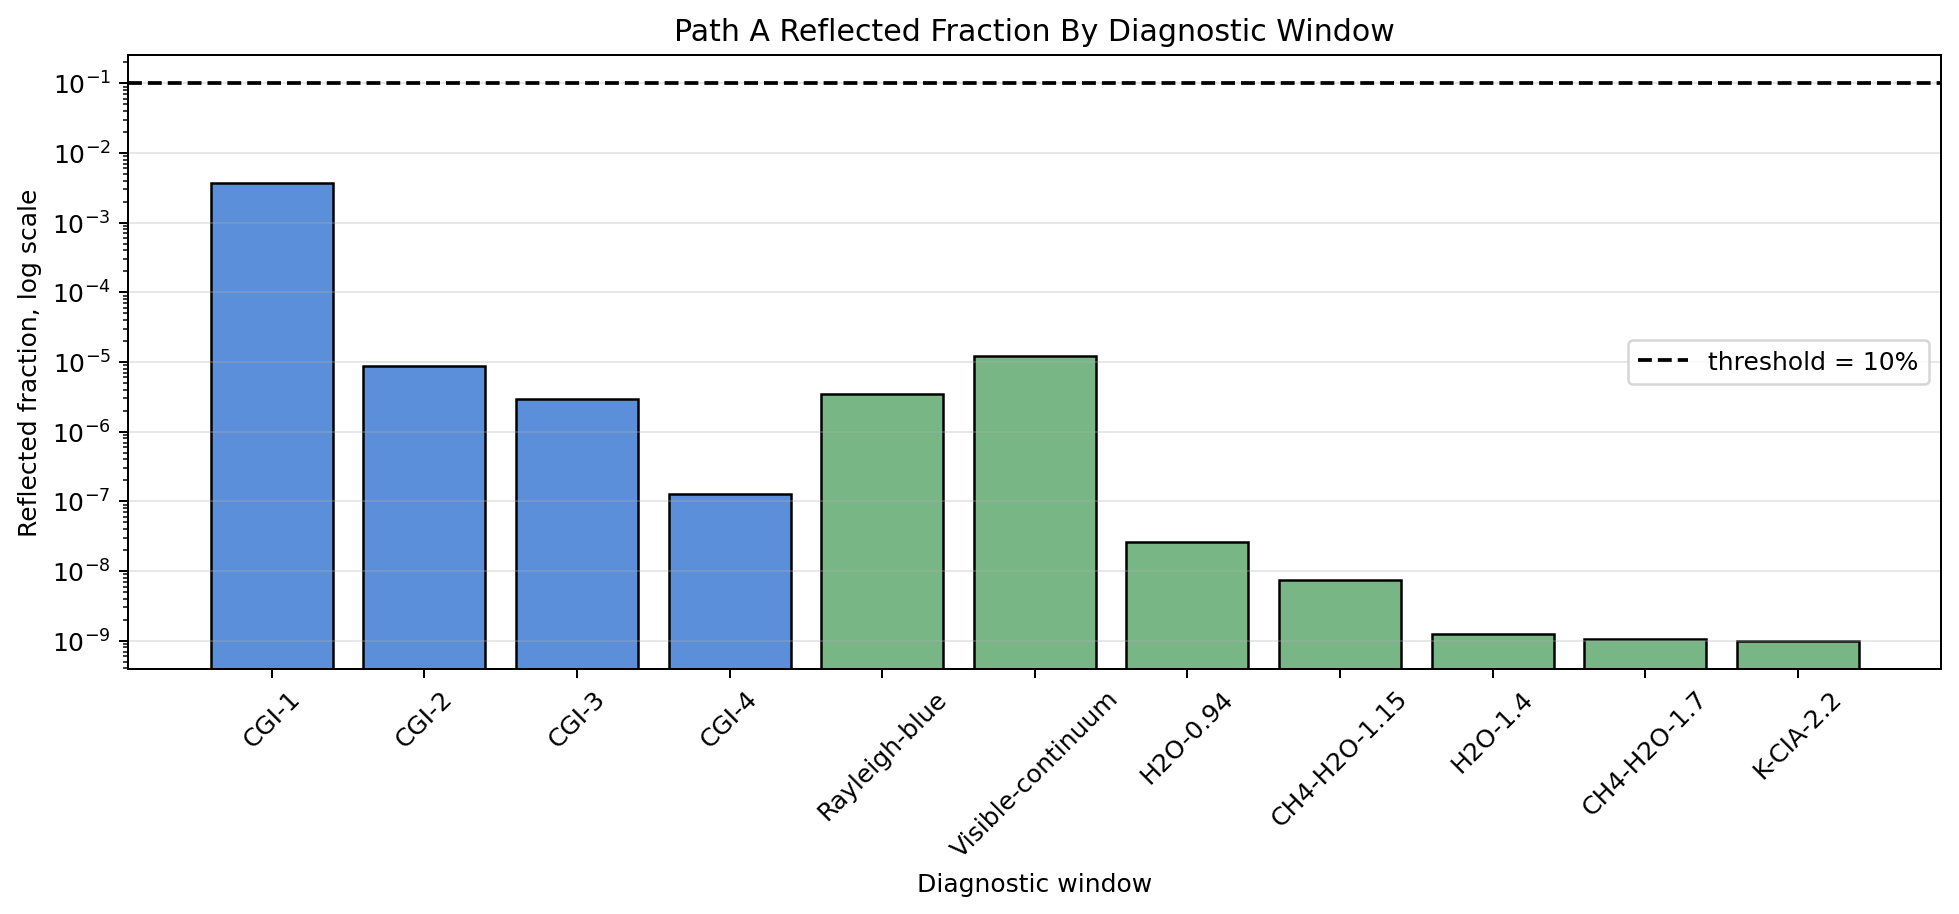

Wrote:
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/spectrum.png
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/diagnostic_reflected_fraction.png


In [10]:
def positive_only(values):
    values = np.asarray(values, dtype=float)
    return np.where(values > 0, values, np.nan)

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.plot(lam_um, positive_only(fp_reflected), label="Reflected", linewidth=1.8)
ax.plot(lam_um, positive_only(fp_thermal), label="Thermal", linewidth=1.8)
ax.plot(lam_um, positive_only(fp_reflected + fp_thermal), label="Total", linewidth=1.8, linestyle="--")

# for idx, (window_name, (lo, hi)) in enumerate(PROPOSAL_WINDOWS.items()):
#     ax.axvspan(lo, hi, color="#d7ecf7" if idx % 2 == 0 else "#edf6fb", alpha=0.45)
#     ax.text((lo + hi) / 2, 0.98, window_name, transform=ax.get_xaxis_transform(),
#             ha="center", va="top", fontsize=8, rotation=90)

ax.set_yscale("log")
ax.set_xlim(PROPOSAL_WAVELENGTH_MIN_UM, PROPOSAL_WAVELENGTH_MAX_UM)
ax.set_xlabel("Wavelength (micron)")
ax.set_ylabel("Planet flux")
ax.set_title("Path A Full PICASO Spectrum, Proposal Range")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "spectrum.png", dpi=180, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(RESULT_DIR / "spectrum.png")))

fig, ax = plt.subplots(figsize=(11, 5.2))
plot_df = metric_df.copy()
plot_df["plot_f_reflect"] = plot_df["f_reflect"].clip(lower=1e-9)
colors = np.where(plot_df["kind"].eq("Roman CGI"), "#5b8fd9", "#78b785")
ax.bar(plot_df["window"], plot_df["plot_f_reflect"], color=colors, edgecolor="black")
ax.axhline(REFLECT_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"threshold = {REFLECT_THRESHOLD:.0%}")
ax.set_yscale("log")
ax.set_ylabel("Reflected fraction, log scale")
ax.set_xlabel("Diagnostic window")
ax.set_title("Path A Reflected Fraction By Diagnostic Window")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "diagnostic_reflected_fraction.png", dpi=180, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(RESULT_DIR / "diagnostic_reflected_fraction.png")))

print("Wrote:")
for path in [RESULT_DIR / "spectrum.png", RESULT_DIR / "diagnostic_reflected_fraction.png"]:
    print(f"- {path}")

## 11. Interpretation In Proposal Language

This single run is not the final proposal grid; it is one grid point. The proposal-level next step is to repeat this calculation over host-star type, separation, metallicity, clouds, and temperature/internal heat assumptions.

For this one case, the useful outputs are:

- the broad spectrum shape from `0.3-2.5 micron`,
- the blue slope and visible continuum behavior,
- the water/methane-sensitive near-infrared windows,
- the reflected-vs-thermal balance in each window,
- the metadata needed to reproduce the point in a larger grid.

That makes the notebook a seed for the documented spectral library described in the proposal.

## 12. Validation

The final cell checks that the notebook produced the expected Path A artifacts and that the main numerical outputs are finite.

In [11]:
expected_files = [
    RESULT_DIR / "summary.json",
    RESULT_DIR / "diagnostic_metrics.csv",
    RESULT_DIR / "spectrum.csv",
    RESULT_DIR / "spectrum.png",
    RESULT_DIR / "diagnostic_reflected_fraction.png",
    RESULT_DIR / "cloud_comparison_spectrum.csv",
    RESULT_DIR / "cloud_free_vs_cloudy.png",
]

assert LAM_GRID.min() == PROPOSAL_WAVELENGTH_MIN_UM
assert LAM_GRID.max() == PROPOSAL_WAVELENGTH_MAX_UM
assert LAM_GRID.size == 2201
assert set(CGI_BANDS).issubset(set(metric_df["window"]))
assert set(PROPOSAL_WINDOWS).issubset(set(metric_df["window"]))
assert np.isfinite(metric_df["f_reflect"]).all()
assert np.isfinite(spectrum_df["Fp_reflected"]).all()
assert np.isfinite(spectrum_df["Fp_thermal"]).all()
assert np.isfinite(cloud_comparison_df["geometric_albedo_cloud_free"]).all()
assert np.isfinite(cloud_comparison_df["geometric_albedo_cloudy_virga"]).all()
assert all(path.exists() for path in expected_files)
assert summary["path"] == "A: full PICASO"
assert summary["thermal_source"] == "picaso"
assert summary["atmosphere_source"] == "picaso"
assert summary["wavelength_grid"]["min_um"] == 0.3
assert summary["wavelength_grid"]["max_um"] == 2.5

print("Validation passed for proposal-style Path A notebook outputs.")
for path in expected_files:
    print(f"- {path}")

Validation passed for proposal-style Path A notebook outputs.
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/summary.json
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/diagnostic_metrics.csv
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/spectrum.csv
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/spectrum.png
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/diagnostic_reflected_fraction.png
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/cloud_comparison_spectrum.csv
- /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/path_a_proposal_range/cloud_free_vs_cloudy.png
